# TP n°1 - Analyse du risque d'inondation d'un site industriel

<div style="text-align: right;">
Julie THOMAS
    
<div style="text-align: right;">
Mathias LOMMEL

<div style="text-align: right;">
5MA - 2024

Dans le cadre de ce TP, nous allons étudier les données relative à la crue d'une rivière présentant un risque d’inondation. L'objectif de cette étude est de dimensionner une digue de protection d'un site industriel proche de ce point d'eau (voir schéma ci-dessous).

![schema](Schéma.png)

#### Importation des librairies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

import sklearn as sk
from sklearn.linear_model import LinearRegression

import openturns as ot

## Données disponibles ($\text{Donnees\_debit.csv}$)

Les données que nous avons sont répertoriées dans un fichier .csv. Au sein de celui-ci, nous trouvons 149 mesures annuelles, de 1849 à 1997, indiquant le débit maximal mesuré sur l'année, ainsi que la hauteur maximale de crue mesurée.

#### Caractéristiques des données

In [ ]:
# Importation des données
data = pd.read_csv("Donnees_debit.csv",sep=";",decimal=",")

print("***** Quelques lignes du tableau de données *****")
print(data.head())
print('\n')
print("********** Caratéristiques des données **********")
print(data.iloc[:,1:3].describe())
print("Débit : ",data["Debit_mesure_maximal"].isna().sum()," Données manquantes")
print("Hauteur : ",data["Hauteur_mesuree"].isna().sum()," Données manquantes")

***** Quelques lignes du tableau de données *****
   Annee  Debit_mesure_maximal  Hauteur_mesuree
0   1849                  3854              NaN
1   1926                  3361              6.7
2   1889                  3330              6.7
3   1901                  3320              NaN
4   1960                  3224              6.6


********** Caratéristiques des données **********
       Debit_mesure_maximal  Hauteur_mesuree
count            149.000000       123.000000
mean            1335.429530         3.896748
std              713.899515         1.272337
min              122.000000         1.000000
25%              800.000000         3.100000
50%             1256.000000         3.900000
75%             1695.000000         4.750000
max             3854.000000         7.200000
Débit :  0  Données manquantes
Hauteur :  26  Données manquantes


Les données de débit s'étendent de 122 à 3854 $m^3/s$, avec une moyene de 1335 $m^3/s$; tandis que les données de hauteur s'étendent de 1 à 7.2 m, avec une moyenne de 3.9m. On remarque par ailleurs que la variable $\text{Hauteur\_mesuree}$ contient 26 NA.

#### Visualisation des données

Avant toute chose, nous allons afficher les distributions empiriques des données de Hauteur et de Débit, en affichant leur histogramme respectif.

Text(0.5, 1.0, 'Debit mesuré')

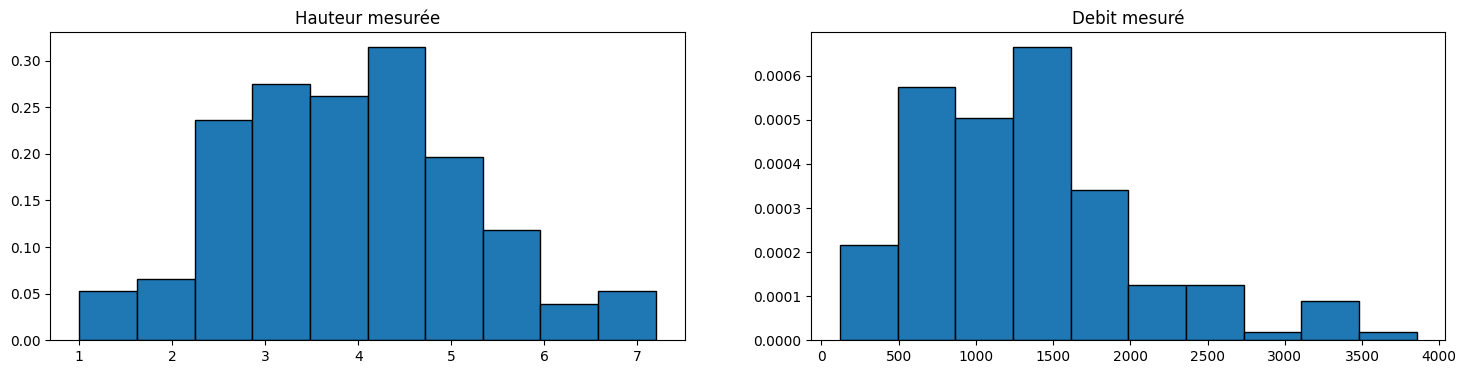

In [ ]:
_, axs = plt.subplots(1,2,figsize=(18,4))
axs[0].hist(data.Hauteur_mesuree, density=True, edgecolor='black')
axs[0].set_title("Hauteur mesurée")
axs[1].hist(data.Debit_mesure_maximal, density=True, edgecolor='black')
axs[1].set_title("Debit mesuré")

Nous pouvons également afficher les hauteurs d'eau mesurées en fonction du débit.

<Axes: title={'center': 'Hauteur en fonction du débit'}, xlabel='Debit_mesure_maximal', ylabel='Hauteur_mesuree'>

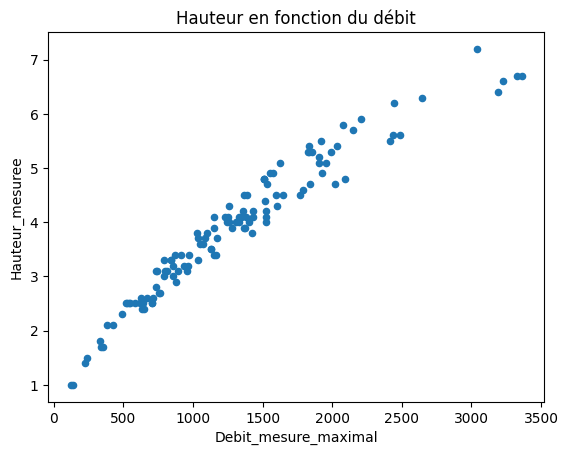

In [ ]:
# Suppression des valeurs manquantes
data = data.dropna()
# Affichage de la hauteur en fonction du débit
data.plot.scatter(x="Debit_mesure_maximal",y="Hauteur_mesuree",title="Hauteur en fonction du débit")

On remarque un lien assez visible entre le débit et la hauteur mesurée. Compte-tenu de l'allure de cette courbe, nous allons proposer de construire un modèle de régression quadratique.

Considérons le modèle suivant : $ \widehat{y} = \beta_0 + \beta_1.x + \beta_2.x^2$.

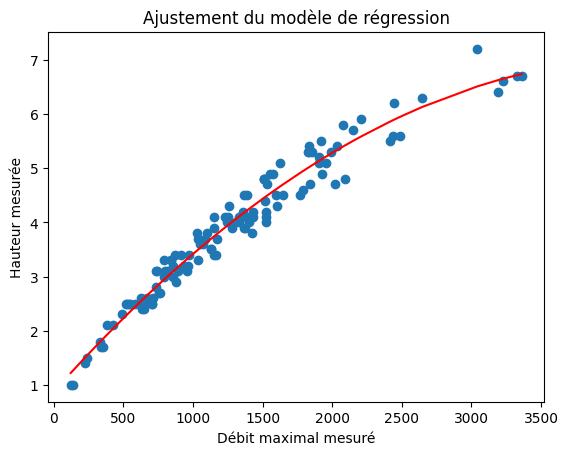

R² = 0.9623399049664507
y* =  0.8737  +  0.0029 .x +  -3e-07 .x²


In [ ]:
# Variable à expliquer
y = data.Hauteur_mesuree
# Variable explicative
x = pd.DataFrame(data = {
    "debit" : data.Debit_mesure_maximal,
    "debit_2" : data.Debit_mesure_maximal**2
})
# Ajustement du modèle de régression
reg = LinearRegression()
reg = reg.fit(x,y)

# Affichage de l'ajustement
y_pred = reg.predict(x)
plt.scatter(data.Debit_mesure_maximal,y)
plt.plot(data.Debit_mesure_maximal,y_pred,color='red')
plt.xlabel("Débit maximal mesuré")
plt.ylabel("Hauteur mesurée")
plt.title("Ajustement du modèle de régression")
plt.show()

print("R² =",sk.metrics.r2_score(y, y_pred))
print("y* = ",np.round(reg.intercept_,4)," + ",np.round(reg.coef_[0],4),".x + ",np.round(reg.coef_[1],7),".x²")

Le modèle ajusté correspond à l'équation suivante : $Hauteur \approx 0.87 + 0.003*Debit$ (le coefficient associé au débit quadratique ne semble pas être significatif).

Nous obtenons un coefficient de détermination $R^2 \approx 0.96$, ce qui est très bon : le modèle appliqué semble donc pertinent et juste dans notre cas d'étude.

## Estimation probabiliste

### Estimation de la loi de probabilité de la hauteur d'eau

Dans l'idée, nous souhaiterions construire une digue qui nous prémunisse contre des crues importantes, avec une proportion assez grande. Nous voulons construire une digue pour laquelle, dans la majorité des cas de crue, la hauteur de la digue soit supérieure à la hauteur d'eau ($Z_b + H_d >  H + Z_v$).

En termes probabilistes, en prenant un risque de niveau $\alpha$, ceci est équivalent à $P(H + Z_v < Z_b + H_d) = P(H < Z_b - Z_v + H_d)  = 1-\alpha$.

Notre problème revient donc à estimer le quantile d'ordre $1-\alpha$ de la loi de probabilité de $H$.Pour pouvoir estimer ce quantile, il faut d'abord connaître la loi probabiliste de la variable aléatoire H.

D'après l'allure de l'histogramme des hauteurs, nous pouvons tenter d'utiliser une loi normale pour caractériser la distribution des hauteurs.

Nous allons essayer d'estimer les paramètres de cette loi, en passant par la moyenne et l'écart-type de notre jeu de données. Nous pourrons ensuite utiliser le test de Kolmogorov-Smirnov pour vérifier que notre hypothèse est correcte, ou du moins, relativement correcte.

In [ ]:
# Moyenne et écart-type de notre jeu de données
moy_H = np.mean(data.Hauteur_mesuree)
std_H = np.std(data.Hauteur_mesuree)

# Test de KS pour la loi normale
ks_statistic_n, p_value_n = stats.kstest(data.Hauteur_mesuree, 'norm', args=(moy_H, std_H))

print("***** Test de Kolmogorov Smirnov *****")
print(f"     Statistique K-S: {np.round(ks_statistic_n,3)}")
print(f"     p_value: {np.round(p_value_n,3)}")


***** Test de Kolmogorov Smirnov *****
     Statistique K-S: 0.062
     p_value: 0.702


D'après les résultats de ce test, avec un risque de seconde espèce de 5%, nous ne rejetons pas l'hypothèse nulle $H_0$ (la p-value étant nettement supérieure à 0.05). Notre postulat initial d'appliquer une loi normale n'est donc pas remis en cause.

Nous pouvons d'ailleurs superposer la densité trouvée avec l'histogramme des valeurs de H.

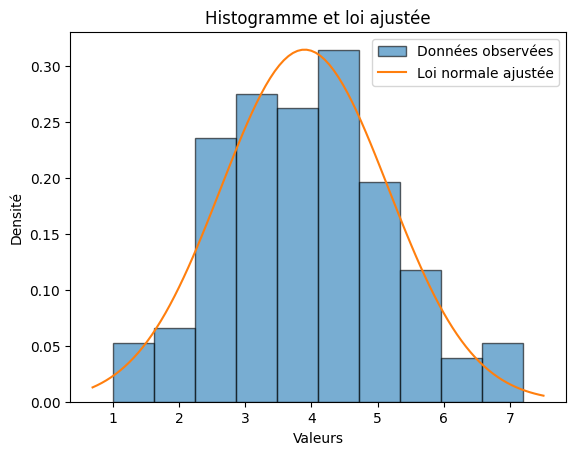

In [ ]:
# Visualisation
# Histogramme des données
plt.hist(data.Hauteur_mesuree, bins=10, density=True, alpha=0.6, edgecolor='black', label='Données observées')

# Courbe de la loi de normale ajustée
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p_n = stats.norm.pdf(x, loc=moy_H, scale=std_H)
plt.plot(x, p_n, label='Loi normale ajustée')

plt.xlabel('Valeurs')
plt.ylabel('Densité')
plt.title('Histogramme et loi ajustée')
plt.legend()

Comme prévu, on observe une certaine proximité entre les deux représentations, ce qui est rassurant.

### Estimation de la hauteur de la digue

Avec la loi obtenue, nous pouvons désormais évaluer le quantile d'ordre $\alpha$, pour un $\alpha$ donné.

Nous pouvons tester les résultats pour $\alpha=1\%$, $\alpha=0.1\%$ et $\alpha=0.01\%$, correspondant à une digue protégeant de $99\%$, $99.9\%$ et $99.99\%$ des plus hautes crues respectivement.

In [ ]:
# Valeurs numériques
Z_b = 55.5
Z_v = 50

# Erreur admise dans les 3 cas cités
alpha_1 = 0.01
alpha_01 = 0.001
alpha_001 = 0.0001

# Détermination des quantiles correspondant
quantile_1 = stats.norm.ppf(1-alpha_1, loc=moy_H, scale=std_H)
quantile_01 = stats.norm.ppf(1-alpha_01, loc=moy_H, scale=std_H)
quantile_001 = stats.norm.ppf(1-alpha_001, loc=moy_H, scale=std_H)

D'après l'équation établie précédemment, nous avons : $P(H < Z_b - Z_v + H_d)  = 1-\alpha$.

En notant $q_{\alpha}$ le quantile obtenu, nous avons finalement : $q_{\alpha} = Z_b - Z_v + H_d \iff H_d = q_{\alpha} + Z_v - Z_b$.

In [ ]:
Hd_1 = quantile_1 + (Z_v - Z_b)
Hd_01 = quantile_01 + (Z_v - Z_b)
Hd_001 = quantile_001 + (Z_v - Z_b)

print("***** Hauteur de digue estimée *****")
print("- Au risque 1% : ", np.round(Hd_1,3),"m")
print("- Au risque 0.1% : ", np.round(Hd_01,3),"m")
print("- Au risque 0.01% : ", np.round(Hd_001,3),"m")

***** Hauteur de digue estimée *****
- Au risque 1% :  1.345 m
- Au risque 0.1% :  2.313 m
- Au risque 0.01% :  3.109 m


Tout d'abord, on observe que la hauteur estimée de la digue augmente lorsque la risque diminue, ce qui est rassurant. En étant le plus sécuritaire possible, une digue de 3.1m serait théoriquement capable de se protéger contre $99.99\%$ des plus hautes crues.

## Estimation par Monte-Carlo

Dans cette deuxième partie, nous allons utiliser des méthodes probabilistes. Nous allons considérer le cas où aucune donnée de Hauteur n’est disponible. Nous utiliserons donc une équation physique, liant la hauteur d'eau aux différents paramètres du problème.

D'après les experts métier, cette équation est la suivante :

$$
H = \left( \frac{Q}{K_s \cdot B \cdot \sqrt{\frac{Z_m - Z_v}{L}}} \right)^{3/5}
$$

Avec :
- $Q~$   : le débit d'eau mesuré
- $K_s$ : le coefficient de frottement du cours d'eau sur son lit
- $B~$   : la longueur du cours d'eau
- $Z_m$ : l'altitude amont
- $Z_v$ : la hauteur du lit du cours d'eau
- $L~$   : la longueur du tronçon de la rivière

Nous savons d'ailleurs que $B=300m$, $L=5000m$, et, pour $K_s$, $Z_m$ et $Z_v$, nous avons une connaissance partielle de leurs valeurs :
- $Z_v \approx 50 m$, (on sait que $49 \le Z_v \le 51$)
- $Z_m \approx 55 m$, (on sait que $54 \le Z_m \le 56$)
- $K_s \sim \mathcal{N}(\mu, \sigma^2)$, avec $\mu = 30$ et $\sigma= 7.5$

Concernant la loi de $Q$, les informations métier révèlent que nous pouvons utiliser une loi de $Gumbel$.

La loi de $Gumbel$ possède 2 paramètres ($\mu$ réel, et $\beta$ >0), et a pour caractéristiques :
- Densité : $f_G(x) = \frac{1}{\beta}.exp(-e^{-\frac{x-\mu}{\beta}}).e^{-\frac{x-\mu}{\beta}}$
- Fonction de répartition : $F_G(x) = exp(-e^{-\frac{x-\mu}{\beta}})$

A noter que son espérance vaut $\mu + \beta.\gamma$, où $\gamma$ est la *constante d'Euler-Mascheroni*, et sa variance vaut $\frac{\pi^2}{6}.\beta^2$.

In [ ]:
# Ajustement de la loi de Gumbel aux données de débit
mu, beta = stats.gumbel_r.fit(data.Debit_mesure_maximal)

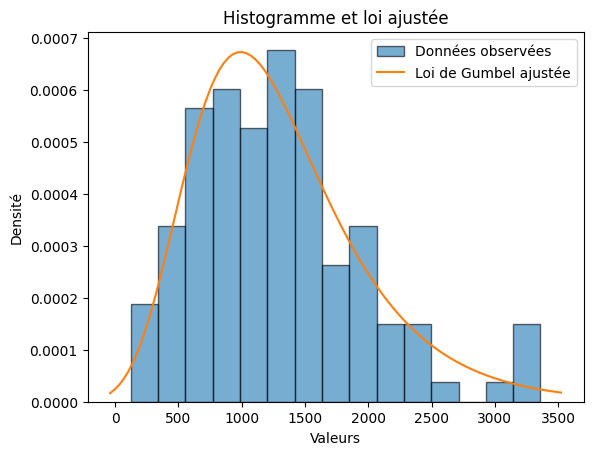

In [ ]:
# Visualisation
# Histogramme des données
plt.hist(data.Debit_mesure_maximal, bins=15, density=True, alpha=0.6, edgecolor='black', label='Données observées')

# Courbe de la loi de Gumbel ajustée
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p_n = stats.gumbel_r.pdf(x, loc=mu, scale=beta)
plt.plot(x, p_n, label='Loi de Gumbel ajustée')

plt.xlabel('Valeurs')
plt.ylabel('Densité')
plt.title('Histogramme et loi ajustée')
plt.legend()

Comme prévu, l'hitogramme est assez fidèle aux données récoltées, ce qui est rassurant. Nous simulerons donc les valeurs de débit avec une loi de $Gumbel$, de paramètres $\mu= 1013$ et $\beta=558$.

Concernant les lois de $Z_m$ et $Z_v$, nous proposons d'utiliser une loi uniforme, avec support $[49,51]$ pour $Z_v$, et $[54,56]$ pour $Z_m$.

Nous pourvons désormais construire la fonction permettant de réaliser le calcul de la hauteur d'eau en fonction des paramètres $Q$, $K_s$, $Z_m$, $Z_v$ et en fonction de $B$ et $L$.

In [ ]:
def compute_H(Q,K_s,Z_m,Z_v):
    """
    Calcule la hauteur d'eau théorique en fonction des paramètres d'entrée.

    Entrées :
        - Q   : Float - Débit d'eau mesuré
        - K_s : Float - Coefficient de frottement du cours d'eau sur son lit
        - Z_m : Float - Altitude amont
        - Z_v : Float - Hauteur du lit du cours d'eau

    Sortie :
        - H : Float - Hauteur d'eau théorique
    """
    # Données connues
    B = 300
    L = 5000
    # Calcul de la hauteur
    H = ( Q / (K_s*B*np.sqrt( (Z_m-Z_v)/L )) )**(3/5)

    return  H

La prochaine étape est de réaliser une propagation d’incertitudes, en utilisant la fonction $\text{compute_H}$, afin de quantifier le risque associé à la surverse éventuelle de la rivière. Nous générerons des échantillons aléatoires selon les lois des entrées, présentées précédemment, et nous estimerons le risque via une approche de type $\text{Monte-Carlo}$.

In [ ]:
# Nombre de valeurs souhaitées
n_echantillons = 10000

# On ne conserve que les valeurs positives de débit
Q = np.clip(stats.gumbel_r.rvs(loc=mu, scale=beta, size=n_echantillons),0,None)
K_s = np.random.normal(30,7.5, n_echantillons)

Z_m = np.random.uniform(54,56,n_echantillons)
Z_v = np.random.uniform(49,51,n_echantillons)

# Création des hauteurs théoriques
H = compute_H(Q,K_s,Z_m,Z_v)

Avec ces données simulées, nous proposons de superposer l'histogramme des valeurs obtenues, avec les données de débit du jeu de données. Nous nous attendons donc à obtenir une distribution similaire.

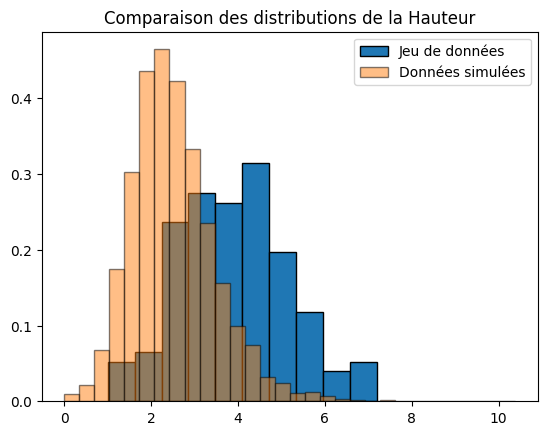

In [ ]:
plt.hist(data.Hauteur_mesuree, density=True, edgecolor='black',label='Jeu de données')
plt.hist(H, bins=30,density=True, edgecolor='black',alpha=0.5,label='Données simulées')
plt.title("Comparaison des distributions de la Hauteur")
plt.legend()

On observe ici que la distribution semble proche, mais décalée vers des valeurs plus basses. Il se peut que cet écart soit lié au faible nombre de données réelles disponibles...

Aussi, nous avons ici utilisé une équation physique modélisant le lien entre la hauteur et les différents paramètres à disposition. Il se peut également que cette équation simplifie la réalité, et soit basé sur certaines hypothèses qui ne s'appliquent pas exactement dans notre cas d'étude.

In [ ]:
mean = np.mean(H)          # Moyenne
median = np.median(H)      # Médiane
std_dev = np.std(H)        # Écart-type
min_value = np.min(H)      # Valeur minimale
max_value = np.max(H)      # Valeur maximale
sum_value = np.sum(H)      # Somme

summary = {
    'Mean': mean,
    'Median': median,
    'Standard Deviation': std_dev,
    'Min': min_value,
    'Max': max_value,
    'Sum': sum_value
}
print("*** Caractéristiques des hauteurs obtenues ***")
summary

*** Caractéristiques des hauteurs obtenues ***


{'Mean': np.float64(2.512592868064855),
 'Median': np.float64(2.399567030401689),
 'Standard Deviation': np.float64(0.9702201862939537),
 'Min': np.float64(0.0),
 'Max': np.float64(10.38297482592111),
 'Sum': np.float64(25125.928680648547)}

Afin de vérifier que cet écart au jeu de données ne soit pas lié à nos propres choix, on se propose d'utiliser 2 autres distributions pour les données $Z_m$ et $Z_v$. Nous pouvons considérer que ces valeurs sont fixes, ou qu'elles provienne td'une loi normale centrée en $55$ et $50$ (avec une variance assez faible pour obtenir des données entre les bornes souhaitées).

In [ ]:
# Z_m et Z_v constants
Z_m_2 = 55
Z_v_2 = 50

# Création des hauteurs théoriques
H_2 = compute_H(Q,K_s,Z_m_2,Z_v_2)

# Z_m et Z_v issus de lois normales
Z_m_3 = np.clip(np.random.normal(55,0.3, n_echantillons),54,56)
Z_v_3 = np.clip(np.random.normal(50,0.3, n_echantillons),49,51)

# Création des hauteurs théoriques
H_3 = compute_H(Q,K_s,Z_m_3,Z_v_3)

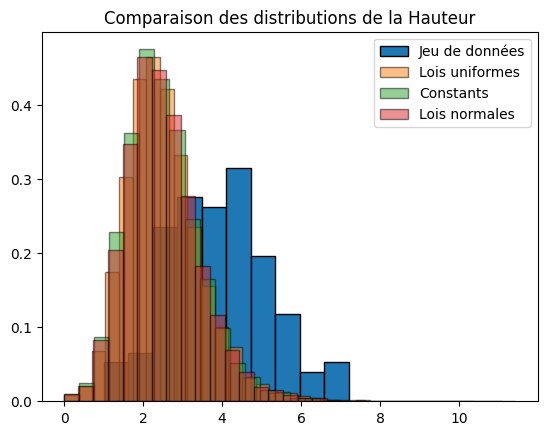

In [ ]:
plt.hist(data.Hauteur_mesuree, density=True, edgecolor='black',label='Jeu de données')
plt.hist(H, bins=30,density=True, edgecolor='black',alpha=0.5,label='Lois uniformes')
plt.hist(H_2, bins=30,density=True, edgecolor='black',alpha=0.5,label='Constants')
plt.hist(H_3, bins=30,density=True, edgecolor='black',alpha=0.5,label='Lois normales')
plt.title("Comparaison des distributions de la Hauteur")
plt.legend()

Nous pouvons voir ici que nos considérations ne semblent pas être la cause de cet écart.

Dans la suite, nous conserverons donc les données de hauteurs simulées avec une loi uniforme.

A l'aide de ces données simulées, nous pouvons désormais estimer les quantiles souhaités.

In [ ]:
quantile2_1 = np.percentile(H,99)
quantile2_01 = np.percentile(H,99.9)
quantile2_001 = np.percentile(H,99.99)

Hd2_1 = quantile2_1 + np.mean(Z_v - Z_b)
Hd2_01 = quantile2_01 + np.mean(Z_v - Z_b)
Hd2_001 = quantile2_001 + np.mean(Z_v - Z_b)

print("***** Hauteur de digue estimée *****")
print("- Au risque 1% : ", np.round(Hd2_1,3),"m")
print("- Au risque 0.1% : ", np.round(Hd2_01,3),"m")
print("- Au risque 0.01% : ", np.round(Hd2_001,3),"m")

***** Hauteur de digue estimée *****
- Au risque 1% :  -0.013 m
- Au risque 0.1% :  1.936 m
- Au risque 0.01% :  3.88 m


## Estimation par Cumul quadratique

Dans cette dernière partie, on se propose d'utiliser la méthode du cumul-quadratique, via le package *openturns*, afin d'observe si nous obtenons des résultats cohérents par rapport aux données disponibles.

Nous devons ici considérer que les paramètres d'entrée suivent une loi normale. Nous considèrerons donc $Z_m$ et $Z_v$ comme constants, et $K_s$ et $Q$ comme suivant une loi normale.

In [ ]:
# Fonction créant des valeurs pour H
H_func = ot.SymbolicFunction(['Q', 'K_s'],['( Q / (K_s*300*sqrt( (55-50)/5000 )) )^(3/5)'])
# Distribution de probabilité des paramètres
distribution = ot.Normal([np.mean(data.Debit_mesure_maximal),30], [np.std(data.Debit_mesure_maximal), 7.5])

# Vecteur des deux distributions
X = ot.RandomVector(distribution)

# Vecteur sortie de la fonction génératrice
Y = ot.CompositeRandomVector(H_func, X)

# Décomposition de Taylor de la sortie
TaylorExpansion = ot.TaylorExpansionMoments(Y)

# Moyenne et écart type estimé par linéarisation
moy_CQ = TaylorExpansion.getMeanFirstOrder()[0]
std_CQ = np.sqrt(TaylorExpansion.getCovariance()[0,0])

print("Valeurs estimées par cumul quadratique : ")
print("   - Moyenne: ",moy_CQ)
print("   - Ecart-type: ",std_CQ)
print("")
print("Valeurs issues des données : ")
print("   - Moyenne: ",moy_H)
print("   - Ecart-type: ",std_H)

Valeurs estimées par cumul quadratique : 
   - Moyenne:  2.491635701268488
   - Ecart-type:  0.8634224873734924

Valeurs issues des données : 
   - Moyenne:  3.8967479674796746
   - Ecart-type:  1.267154481977259


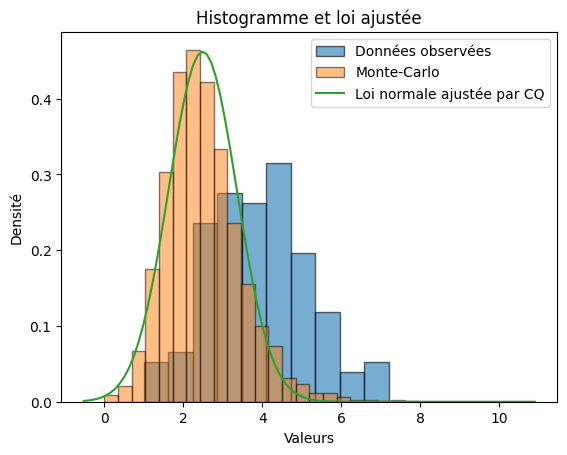

In [ ]:
# Visualisation
# Histogramme des données
plt.hist(data.Hauteur_mesuree, bins=10, density=True, alpha=0.6, edgecolor='black', label='Données observées')
plt.hist(H, bins=30,density=True, edgecolor='black',alpha=0.5,label='Monte-Carlo')

# Courbe de la loi de normale ajustée
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p_n = stats.norm.pdf(x, loc=moy_CQ, scale=std_CQ)
plt.plot(x, p_n, label='Loi normale ajustée par CQ')

plt.xlabel('Valeurs')
plt.ylabel('Densité')
plt.title('Histogramme et loi ajustée')
plt.legend()

Nous pouvons voir ci-dessus que les données obtenues par Cumul-Quadratique sous estiment les valeurs réelles (obtenues via les données). Toutefois, on observe ici que la distribution semble être assez fidèle au résultats obtenus par la méthode de $Monte-Carlo$.

## Bilan

Finalement, nous pouvons réaliser un bilan des hauteurs de digue, selon le niveau de sûreté que nous souhaitons appliquer.

In [ ]:
print("***** Hauteur de digue estimée *****")
print("- Au risque 1% : ")
print("         ■ Approche Probabiliste :", np.round(Hd_1,3),"m")
print("         ■ Approche Monte-Carlo :", np.round(Hd2_1,3),"m")
print("- Au risque 0.1% : ")
print("         ■ Approche Probabiliste ", np.round(Hd_01,3),"m")
print("         ■ Approche Monte-Carlo :", np.round(Hd2_01,3),"m")
print("- Au risque 0.01% : ")
print("         ■ Approche Probabiliste ", np.round(Hd_001,3),"m")
print("         ■ Approche Monte-Carlo :", np.round(Hd2_001,3),"m")

***** Hauteur de digue estimée *****
- Au risque 1% : 
         ■ Approche Probabiliste : 1.345 m
         ■ Approche Monte-Carlo : -0.013 m
- Au risque 0.1% : 
         ■ Approche Probabiliste  2.313 m
         ■ Approche Monte-Carlo : 1.936 m
- Au risque 0.01% : 
         ■ Approche Probabiliste  3.109 m
         ■ Approche Monte-Carlo : 3.88 m


D'après les résultats, si nous considérons le cas le plus sécuritaire, à savoir, de se prémunir des surverses dans 99.99% des cas (probabilité de surverse de $10^{-4}$), ce qui semble assez cohérent compte tenu du risque associé, une hauteur de berge de 3.8m environ semble la plus adéquate.

Il semblerait d'ailleurs que la méthode de Monte-Carlo soit plus sécuritaire que l'approche probabiliste.